# Ultimate Data Science Challenge

In [36]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


In [37]:
LOGIN_PATH = "../data/logins.json"
RETENTION_PATH = "../data/ultimate_data_challenge.json"

## Part 1 - Login Data Analysis

In [38]:
#=== LOGIN DATA ===#
with open(LOGIN_PATH, "r") as f:
    logins_raw = json.load(f)

logins = pd.DataFrame(logins_raw)
logins["login_time"] = pd.to_datetime(logins["login_time"])

print("Shape:", logins.shape)
display(logins.head())
print("Date range:", logins["login_time"].min(), "to", logins["login_time"].max())


Shape: (93142, 1)


,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


Date range: 1970-01-01 20:12:16 to 1970-04-13 18:57:38


In [39]:
logins.dtypes

login_time    datetime64[ns]
dtype: object

In [40]:
#=== CHECK MISSING VALUES ===#
display(logins.isna().sum())

duplicate_rows = logins.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows:,}")

login_time    0
dtype: int64

Duplicate rows: 877


In [41]:
login_15min = (
    logins
    .set_index("login_time")
    .resample("15min")
    .size()
    .rename("login_count")
    .to_frame()
)

# Added features so we can model by different intervals
login_15min["hour"] = login_15min.index.hour
login_15min["dayofweek"] = login_15min.index.dayofweek
login_15min["weekday_name"] = login_15min.index.day_name()
login_15min["is_weekend"] = login_15min["dayofweek"] >= 5
login_15min["minutes_since_midnight"] = (
    login_15min.index.hour * 60 + login_15min.index.minute
)

display(login_15min.head())
print(login_15min["login_count"].describe())

,login_count,hour,dayofweek,weekday_name,is_weekend,minutes_since_midnight
login_time,,,,,,
1970-01-01 20:00:00,2,20,3,Thursday,False,1200
1970-01-01 20:15:00,6,20,3,Thursday,False,1215
1970-01-01 20:30:00,9,20,3,Thursday,False,1230
1970-01-01 20:45:00,7,20,3,Thursday,False,1245
1970-01-01 21:00:00,1,21,3,Thursday,False,1260


count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
Name: login_count, dtype: float64


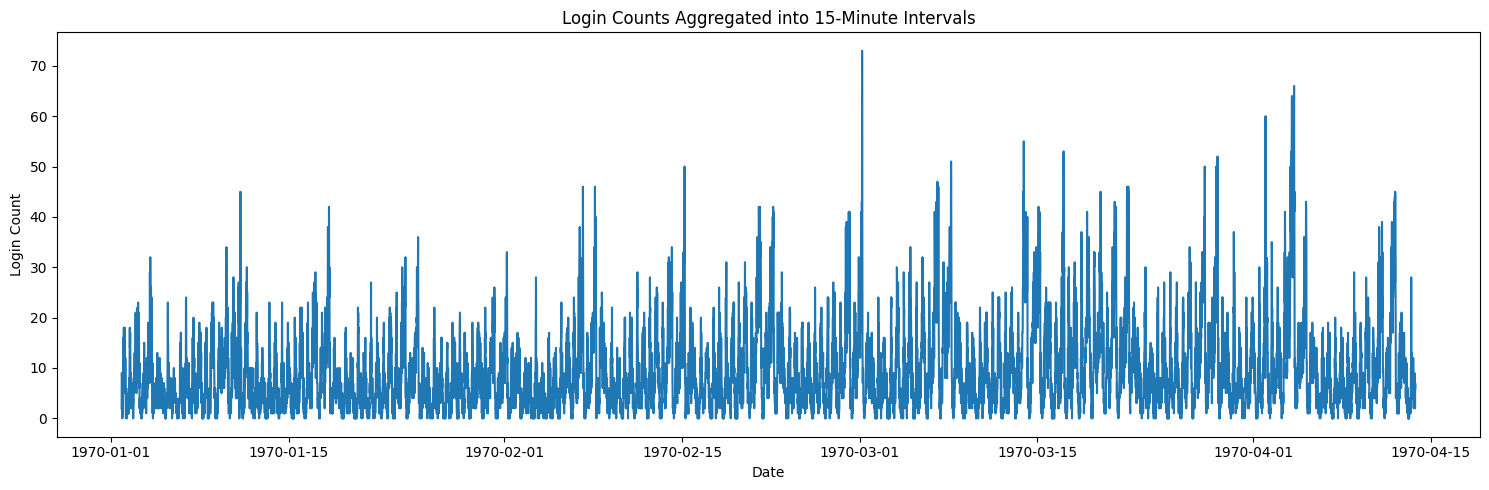

In [42]:
# === PLOTTING TIME SERIES IN 15 MIN INTERVAL === #
plt.figure(figsize=(15, 5))
plt.plot(login_15min.index, login_15min["login_count"])
plt.title("Login Counts Aggregated into 15-Minute Intervals")
plt.xlabel("Date")
plt.ylabel("Login Count")
plt.tight_layout()
plt.show()

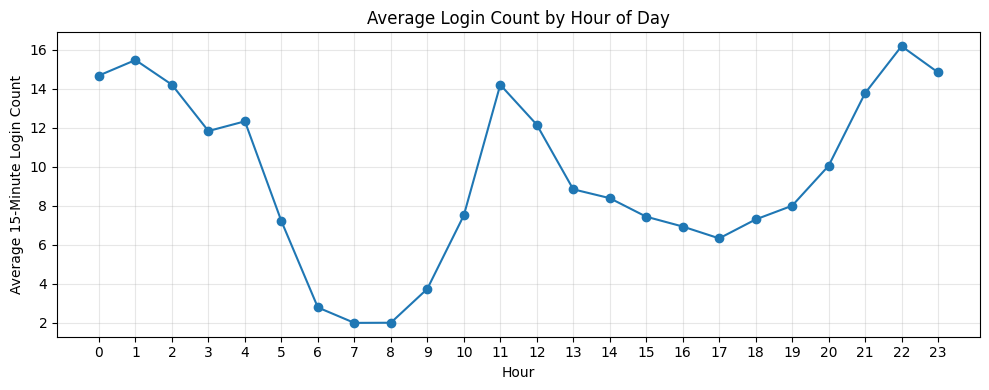

hour
22    16.193627
1     15.482843
23    14.848039
0     14.688725
2     14.215686
11    14.213235
21    13.781863
4     12.338235
12    12.166667
3     11.840686
Name: avg_login_count, dtype: float64

In [43]:
# === PLOTTING TIME SERIES IN HOURLY INTERVAL === #
hourly_profile = login_15min.groupby("hour")["login_count"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")
plt.title("Average Login Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average 15-Minute Login Count")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(hourly_profile.sort_values(ascending=False).head(10).rename("avg_login_count"))


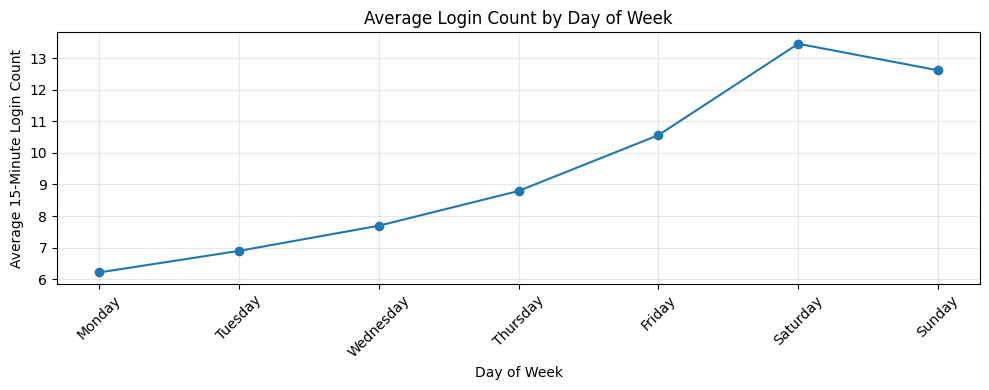

weekday_name
Monday        6.213380
Tuesday       6.895833
Wednesday     7.692708
Thursday      8.794118
Friday       10.561111
Saturday     13.456250
Sunday       12.615972
Name: avg_login_count, dtype: float64

In [44]:
#=== Day of the Week Demand ===#
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_profile = (
    login_15min.groupby("weekday_name")["login_count"]
    .mean()
    .reindex(weekday_order)
)

plt.figure(figsize=(10, 4))
plt.plot(dow_profile.index, dow_profile.values, marker="o")
plt.title("Average Login Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average 15-Minute Login Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(dow_profile.rename("avg_login_count"))

In [45]:
#=== PEAK INTERVALS ===#
top_intervals = login_15min["login_count"].sort_values(ascending=False).head(10)
display(top_intervals)

login_time
1970-03-01 04:30:00    73
1970-04-04 05:30:00    66
1970-04-04 01:30:00    64
1970-04-04 01:15:00    63
1970-04-01 23:30:00    60
1970-04-04 05:00:00    60
1970-04-04 04:45:00    59
1970-04-04 05:15:00    59
1970-04-04 01:45:00    56
1970-03-13 22:15:00    55
Name: login_count, dtype: int64

## Part 1 - Analysis

- Peak demand is between 10PM and 2AM
- Demand builds through the week and is strongest on Friday, Saturday, and Sunday.

## Part 2 - Experiment and Metrics Design

The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on
weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active
during the day. On weekends, there is reasonable activity in both cities.

However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend
to be exclusive to each city. The Ultimate managers of city operations for the two cities have
proposed an experiment to encourage driver partners to be available in both cities, by
reimbursing all toll costs.

#### 1. What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?
##### I would choose cross **city driver participation rate** as the goal is to encourage drivers to be available in both cities
##### **Cross city driver participation rate:**
The proportion of active driver partners who complete at least one trip in **both** cities

#### 2. Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on:
##### a) how you will implement the experiment
A practical design is a **randomized controlled experiment at the driver level**.

- Randomly assign eligible driver partners into:
  - **Treatment**: toll reimbursements enabled
  - **Control**: current system, no reimbursement
- Run the test long enough to capture both **weekday and weekend** behavior, ideally at least **2–4 weeks**
- Use the same reimbursement rules throughout the test
- Track trips, crossings, and city activity for both groups

##### b) what statistical test(s) you will conduct to verify the significance of the observation
Because the primary metric is a **proportion** (whether a driver served both cities or not), a natural primary test is:

- **Two-proportion z-test**  
or equivalently
- **Chi-square test of independence**

##### c) how you would interpret the results and provide recommendations to the city operations team along with any caveats.
I would compare treatment vs control on the primary metric:

- If treatment significantly increases cross-city driver participation and the economics are favorable, I would recommend expanding the program.
- If participation improves but only at very high reimbursement cost, I would recommend a more targeted version (for example, only during certain hours or only for under-supplied routes).


# Part 3 — Predictive Modeling

1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?

2. Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.

3. Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

---

The goal is to predict whether a **rider** is **retained**, where retention is defined as being active in the **preceding 30 days** relative to the data last pull date.


In [46]:
#=== RETENTION DATA ===#
ultimate = pd.read_json(RETENTION_PATH)

print("Shape:", ultimate.shape)
display(ultimate.head())


Shape: (50000, 12)


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [47]:
ultimate.dtypes

city                       object
trips_in_first_30_days      int64
signup_date                object
avg_rating_of_driver      float64
avg_surge                 float64
last_trip_date             object
phone                      object
surge_pct                 float64
ultimate_black_user          bool
weekday_pct               float64
avg_dist                  float64
avg_rating_by_driver      float64
dtype: object

In [48]:
#=== DATA CLEANING AND FEATURE ENGINEERING ===#
ultimate["signup_date"] = pd.to_datetime(ultimate["signup_date"])
ultimate["last_trip_date"] = pd.to_datetime(ultimate["last_trip_date"])

observation_date = ultimate["last_trip_date"].max()
ultimate["retained"] = ultimate["last_trip_date"] >= (observation_date - pd.Timedelta(days=30))

print("Observation date:", observation_date)
print("Retention rate:", ultimate["retained"].mean())

Observation date: 2014-07-01 00:00:00
Retention rate: 0.37608


In [49]:
#=== MISSING VALUE CHECK ===#
missing_pct = (ultimate.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_percent"))

,missing_percent
avg_rating_of_driver,16.244
phone,0.792
avg_rating_by_driver,0.402
city,0.000
trips_in_first_30_days,0.000
signup_date,0.000
avg_surge,0.000
last_trip_date,0.000
surge_pct,0.000
ultimate_black_user,0.000


In [50]:
#=== RETENTION RATES BY CATEGORIES ==#
city_retention = ultimate.groupby("city")["retained"].mean().sort_values(ascending=False)
phone_retention = ultimate.groupby("phone")["retained"].mean().sort_values(ascending=False)
black_retention = ultimate.groupby("ultimate_black_user")["retained"].mean()

display(city_retention.rename("retention_rate"))
display(phone_retention.rename("retention_rate"))
display(black_retention.rename("retention_rate"))


city
King's Landing    0.628134
Winterfell        0.351945
Astapor           0.255715
Name: retention_rate, dtype: float64

phone
iPhone     0.448933
Android    0.209426
Name: retention_rate, dtype: float64

ultimate_black_user
False    0.298818
True     0.503713
Name: retention_rate, dtype: float64

**Observations:**
- Users in King's Landing retain at a much higher rate than users in the other cities
- iPhone users retain more than Android users in this sample
- Users who used Ultimate Black in the first 30 days appear more likely to be retained

In [51]:
#=== MODELLING ===#
#Added feature signup day of the week instead of the signup date
ultimate["signup_dayofweek"] = ultimate["signup_date"].dt.day_name()

X = ultimate.drop(columns=["retained", "signup_date", "last_trip_date"])
y = ultimate["retained"].astype(int)

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge', 'surge_pct', 'ultimate_black_user', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver']
Categorical features: ['city', 'phone', 'signup_dayofweek']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [53]:
#=== LOGISTIC REGRESSION AND RANDOM FOREST MODELS ==#
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)


,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.77960,0.696486,0.733674,0.714596,0.851853
0,Logistic Regression,0.71512,0.662950,0.493299,0.565679,0.755363


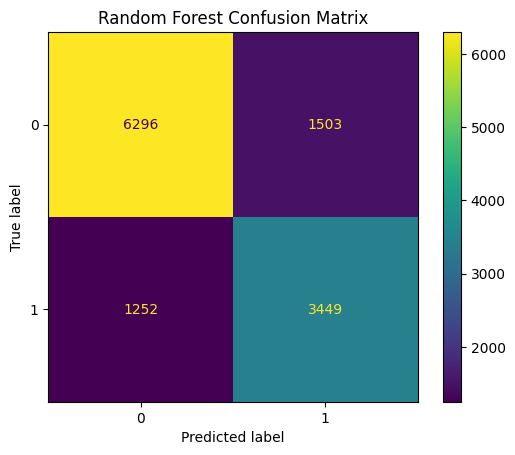

In [54]:
#=== Confusion Matrix ===#
best_model = random_forest
best_model.fit(X_train, y_train)

best_preds = best_model.predict(X_test)
best_probs = best_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, best_preds)
plt.title("Random Forest Confusion Matrix")
plt.show()


In [55]:
#=== FEATURE IMPORTANCE ===#

# Extract onehotencoder from pipeline
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

# Get categorical feature names from onehotencoder step
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))

# Get all feature names numeric + categorical
feature_names = numeric_features + cat_feature_names

rf_importances = pd.Series(
    best_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(rf_importances.head(15).to_frame("importance"))


,importance
avg_rating_by_driver,0.148734
weekday_pct,0.134570
avg_dist,0.115714
surge_pct,0.092717
city_King's Landing,0.088454
trips_in_first_30_days,0.075928
avg_surge,0.073728
avg_rating_of_driver,0.052052
ultimate_black_user,0.048756
phone_iPhone,0.037142


** Observations **

From feature importance from random forest model, the strongest predictors are:
- avg_rating_by_driver
- weekday_pct
- avg_dist

Which tells us that those riders that are well received by drivers, tend to use the service during the week, and use the service to cover more distance are predictive of rentention.

From EDA, people from King's Landing also are more likely to be retention customers as well